In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

data = pd.read_csv(r"C:\Users\SHISHIR RAJ\Desktop\House price prediction.csv")
print(data.head(5))


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [3]:
data.shape

(545, 13)

In [4]:
# Data Preprocessing

obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)
print("Categorical variables:",len(object_cols))

int_ = (data.dtypes == 'int')
num_cols = list(int_[int_].index)
print("Integer variables:",len(num_cols))

fl = (data.dtypes == 'float')
fl_cols = list(fl[fl].index)
print("Float variables:",len(fl_cols))


Categorical variables: 7
Integer variables: 6
Float variables: 0


In [5]:
# Convert 'yes'/'no' to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
data[binary_cols] = data[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0}))

# One-hot encode 'furnishingstatus'
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)

In [6]:
 #Explore the dataset
#Check for missing values, outliers, or categorical columns that need encoding.
# Check for missing values
print(data.isnull().sum())

# Basic statistical summary
print(data.describe())

price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.0000

In [7]:
#Encode Categorical Data

# One-hot encoding for categorical variables
data = pd.get_dummies(data, columns=['mainroad','guestroom','basement',
                            'hotwaterheating','prefarea',
	                    'airconditioning',], drop_first=True)

# Check the transformed data
print(data.head())

      price  area  bedrooms  bathrooms  stories  parking  \
0  13300000  7420         4          2        3        2   
1  12250000  8960         4          4        4        3   
2  12250000  9960         3          2        2        2   
3  12215000  7500         4          2        2        3   
4  11410000  7420         4          1        2        2   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  mainroad_1  \
0                            False                         False        True   
1                            False                         False        True   
2                             True                         False        True   
3                            False                         False        True   
4                            False                         False        True   

   guestroom_1  basement_1  hotwaterheating_1  prefarea_1  airconditioning_1  
0        False       False              False        True               True  


In [8]:
#OneHotEncoder – For Label categorical features
from sklearn.preprocessing import OneHotEncoder

s = (data.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)
print('No. of. categorical features: ', 
      len(object_cols))


Categorical variables:
[]
No. of. categorical features:  0


In [9]:
# Define features and target variable
X_full = data.drop('price', axis=1)  
y = data['price']

# Split the dataset into training and testing sets
X_train_full, X_test_full, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train_full}")
print(f"Testing set size: { X_test_full}")

Training set size:      area  bedrooms  bathrooms  stories  parking  \
46   6000         3          2        4        1   
93   7200         3          2        1        3   
335  3816         2          1        1        2   
412  2610         3          1        2        0   
471  3750         3          1        2        0   
..    ...       ...        ...      ...      ...   
71   6000         4          2        4        0   
106  5450         4          2        1        0   
270  4500         3          2        3        1   
435  4040         2          1        1        0   
102  5500         3          2        4        1   

     furnishingstatus_semi-furnished  furnishingstatus_unfurnished  \
46                             False                         False   
93                              True                         False   
335                            False                         False   
412                            False                          True   
471   

In [10]:
#Train the Linear Regression Model
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train_full,y_train )

# Display the model's coefficients and intercept
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [ 2.35968805e+02  7.67787016e+04  1.09444479e+06  4.07476595e+05
  2.24841913e+05 -1.26881818e+05 -4.13645062e+05  3.67919948e+05
  2.31610037e+05  3.90251176e+05  6.84649885e+05  6.29890565e+05
  7.91426736e+05]
Model Intercept: 260032.35760741308


In [11]:
import time  # Import the time module
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error
import numpy as np  # Assuming you have already imported NumPy

# Start the timer
start_time = time.time()

# Make predictions on the test set
y_pred = model.predict(X_test_full)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {mse}")
print(f"R² Score: {r2}")
accuracy = 100 * (1 - (mae / np.mean(y_test)))
print(f"Custom Regression Accuracy: {accuracy:.2f}%")

# Stop the timer
end_time = time.time()

# Calculate runtime
runtime = end_time - start_time
print(f"Runtime: {runtime:.2f} seconds")

Mean Absolute Error (MAE): 970043.4039201635
Root Mean Squared Error (RMSE): 1324506.9600914386
R² Score: 0.6529242642153184
Custom Regression Accuracy: 80.63%
Runtime: 0.03 seconds


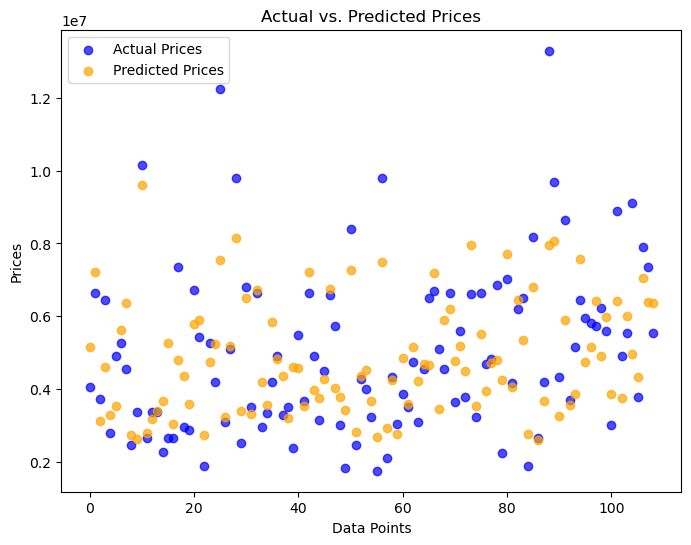

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# Scatter plot for actual prices
plt.scatter(range(len(y_test)), y_test, color='blue', alpha=0.7, label='Actual Prices')
# Scatter plot for predicted prices
plt.scatter(range(len(y_pred)), y_pred, color='orange', alpha=0.7, label='Predicted Prices')

plt.xlabel("Data Points")
plt.ylabel("Prices")
plt.title("Actual vs. Predicted Prices")
plt.legend()  # Add a legend to differentiate the colors
plt.show()


In [13]:
import pandas as pd

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Display the correlation with house price
house_price_corr = correlation_matrix['price'].sort_values(ascending=False)
print(house_price_corr)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_1                  0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_1                         0.329777
mainroad_1                         0.296898
guestroom_1                        0.255517
basement_1                         0.187057
hotwaterheating_1                  0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [14]:
strong_corr = house_price_corr[abs(house_price_corr) > 0.4]
print(strong_corr)

price                1.000000
area                 0.535997
bathrooms            0.517545
airconditioning_1    0.452954
stories              0.420712
Name: price, dtype: float64


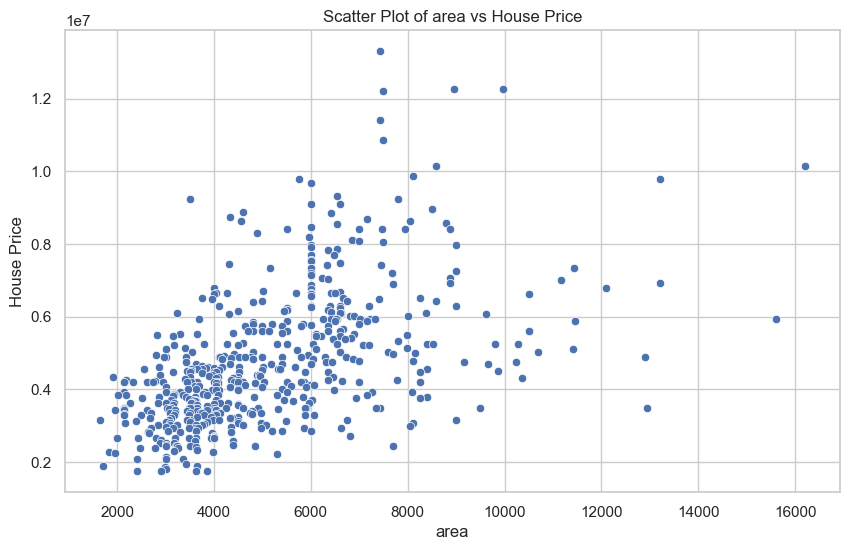

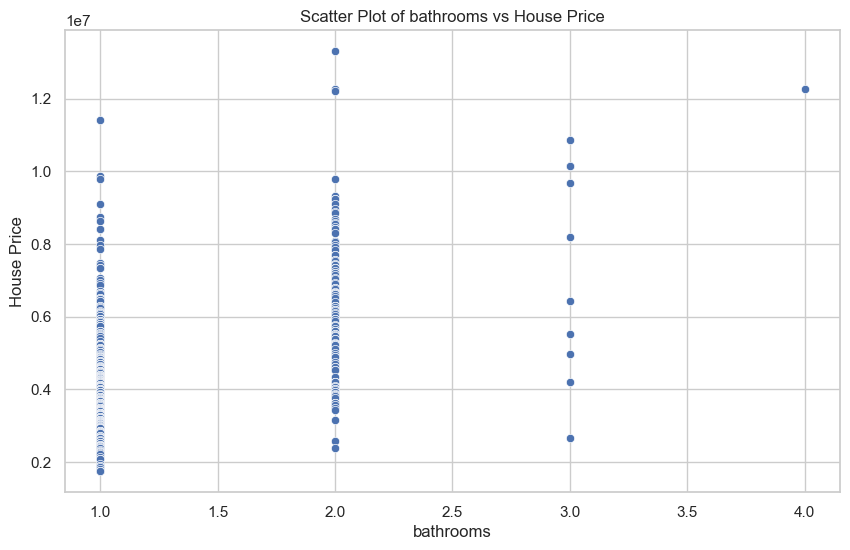

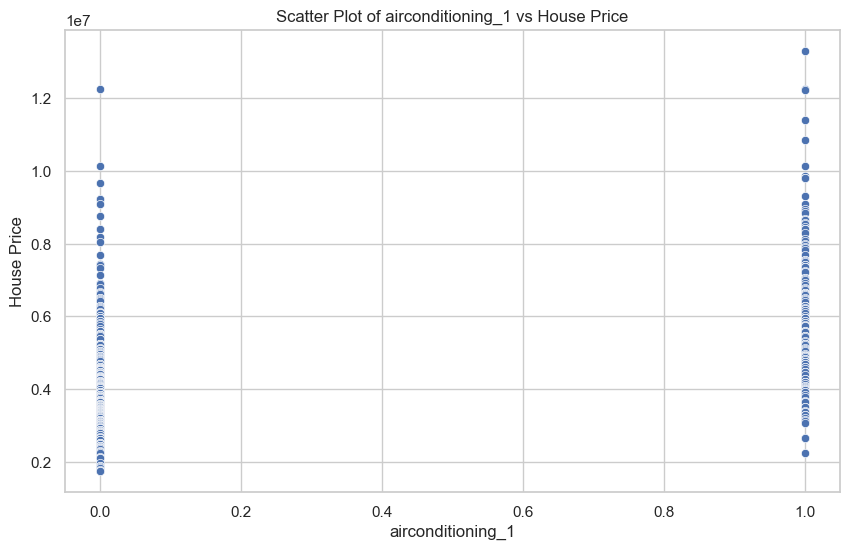

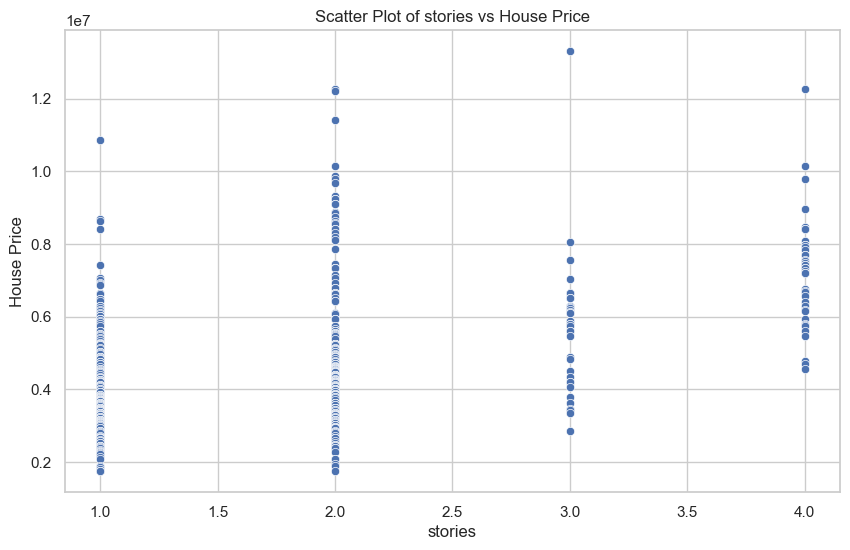

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create scatter plots for strongly correlated features
for feature in strong_corr.index:
    if feature != 'price':  # Avoid plotting house price against itself
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=data, x=feature, y='price')
        plt.title(f'Scatter Plot of {feature} vs House Price')
        plt.xlabel(feature)
        plt.ylabel('House Price')
        plt.show()

In [16]:
import time  # Import time module to measure runtime
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np  # Assuming NumPy is already imported

features = ['area', 'bathrooms', 'airconditioning_1', 'stories', 'parking', 
            'prefarea_1', 'guestroom_1', 'hotwaterheating_1', 'furnishingstatus_semi-furnished']
# 3. Split data into training and testing sets
X = data[features]
y = data['price']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Start the timer
start_time = time.time()

# 4. Train a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)  # Adjust hyperparameters
model.fit(X_train, y_train)

# 5. Make predictions and evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Stop the timer
end_time = time.time()

print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')
# Custom regression accuracy based on MAE
accuracy = 100 * (1 - (mae / np.mean(y_test)))
print(f'Custom Regression Accuracy: {accuracy:.2f}%')

# Calculate runtime
runtime = end_time - start_time
print(f'Runtime: {runtime:.2f} seconds')


Mean Absolute Error: 992166.5363914375
R-squared: 0.6142004091155191
Custom Regression Accuracy: 80.19%
Runtime: 0.67 seconds
